In [13]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [14]:
df=pd.read_csv('06-study_hours_grades.csv')

In [28]:
df['grade'].values

array([30.2039391 , 57.87845188, 46.36840053, 39.33071682, 14.84388804,
       16.3600376 , 11.98290307, 55.42305174, 40.74298717, 41.87754858,
       11.67739265, 57.72532805, 50.26828804, 21.84030811, 21.15324741,
       21.03278573, 23.5336771 , 35.61939683, 32.25977779, 26.51254726,
       39.63429626, 16.60337508, 22.39456248, 25.92567892, 34.42855086,
       51.97127813, 19.83966886, 37.71878772, 40.34400049, 11.03228113,
       41.10003381, 21.60227932, 13.18092757, 60.57356417, 53.04211145,
       52.06367241, 25.4047826 , 14.285591  , 44.39517288, 28.03248686,
       15.66256797, 35.47307065, 14.67521415, 54.42947967, 21.32201187,
       42.12260013, 27.41635804, 36.66090328, 36.27599356, 20.26925764])

In [16]:
X= torch.tensor(df['study_hours'].values)
Y= torch.tensor(df['grade'].values)

In [22]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [18]:
train_split=int(0.8*len(X))

In [20]:
train_split

40

In [21]:
X_train, Y_train= X[:train_split],Y[:train_split]
X_test,Y_test=X[train_split:],Y[train_split:]

In [29]:
X_train,X_test

(tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
         7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
         4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
         5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
         3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64),
 tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
         1.8485], dtype=torch.float64))

In [30]:
len(X_train),len(X_test)

(40, 10)

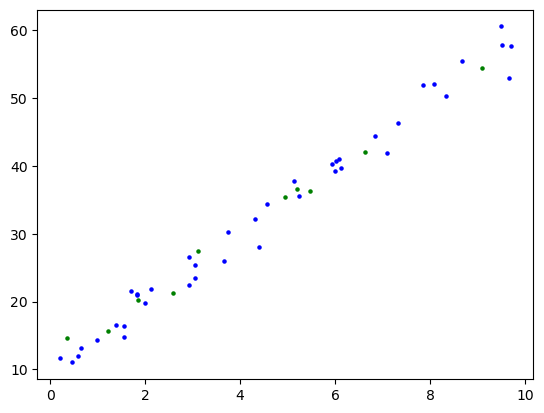

In [42]:

plt.scatter(X_train,Y_train,c='b',s=5,label='traişnişng data')
plt.scatter(X_test,Y_test,c='g',s=5,label='label test data')

plt.show()


In [45]:
import torch.nn as nn
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer=nn.Linear(in_features=1,out_features=1)
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [46]:
torch.manual_seed(42)
model=LinearRegressionModel()

In [47]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [48]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [49]:
loss_fn=nn.MSELoss()

optimizer=torch.optim.SGD(model.parameters(),lr=0.001)

In [50]:
epochs = 120

for epochs in range(epochs):
    model.train()